In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

/Users/nikos/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/nikos/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sys.path.append(os.path.abspath(".."))

from CP.classifier import SplitConformalClassifier
from CP.scores import ClassificationScores
from conformal_evaluation import ClassificationEvaluator

In [4]:
X, y = fetch_openml("mammography", version=1, as_frame=True, return_X_y=True)

y = y.astype(int)

class_labels = sorted(y.unique())
target_names = {
    -1: "negative / non-calcification",
     1: "positive / calcification"
}

print(class_labels)
print(target_names)

[-1, 1]
{-1: 'negative / non-calcification', 1: 'positive / calcification'}


In [5]:
# Split: 60% train, 20% calib, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
print("Train shape :", X_train.shape)
print("Calib shape :", X_calib.shape)
print("Test shape  :", X_test.shape)


# Base classifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Store results
results = {}

for score_type in ["probability", "cumulative"]:
    score = ClassificationScores(score_type=score_type)

    cp = SplitConformalClassifier(
        model=model,
        alpha=0.1,
        score_function=score.compute,
        set_builder=score.build_set
    )

    cp.fit(X_train, y_train, X_calib, y_calib)

    pred_probs = cp.predict_proba(X_test)
    pred_sets = cp.predict_set(X_test)

    y_test_arr = y_test.to_numpy()

    coverage = np.mean([
        y_true in pred_set
        for y_true, pred_set in zip(y_test_arr, pred_sets)
    ])

    avg_set_size = np.mean([len(s) for s in pred_sets])

    results[score_type] = {
        "q_hat": cp.q_hat_,
        "pred_probs": pred_probs,
        "pred_sets": pred_sets,
        "coverage": coverage,
        "avg_set_size": avg_set_size
    }

    print(f"\n=== {score_type.upper()} ===")
    print("q_hat:", cp.q_hat_)
    print("coverage:", coverage)
    print("average set size:", avg_set_size)

Train shape : (6709, 6)
Calib shape : (2237, 6)
Test shape  : (2237, 6)

=== PROBABILITY ===
q_hat: 0.025000000000000022
coverage: 0.9856951274027715
average set size: 1.0

=== CUMULATIVE ===
q_hat: 1.0
coverage: 1.0
average set size: 2.0


/var/folders/qn/yf1dkxd942123kjd7f8sj4p00000gp/T/ipykernel_47343/323408225.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


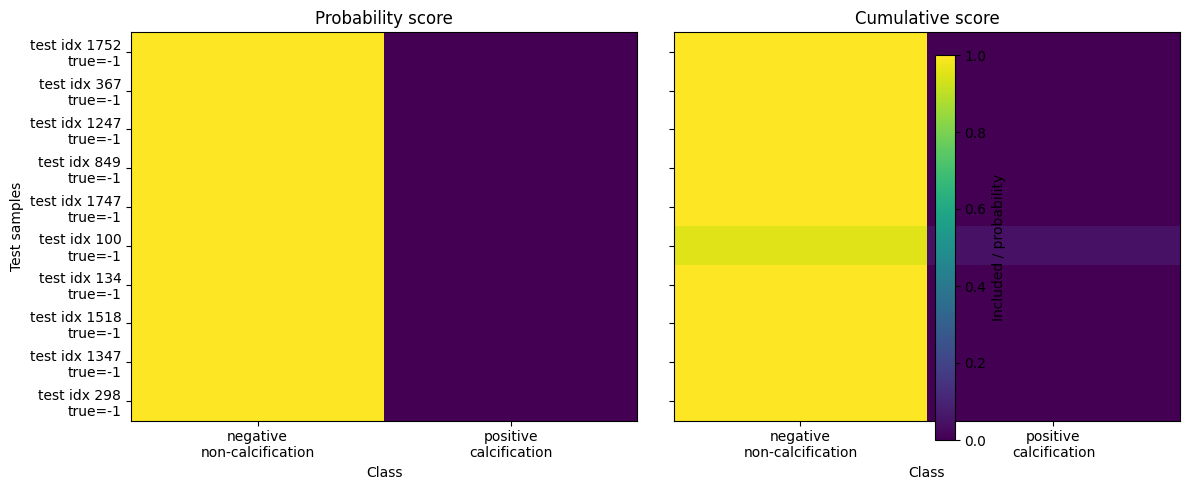

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Basic setup
# -----------------------------
y_test_arr = y_test.to_numpy()

# Use the class order from the fitted model if available.
# Otherwise use sorted unique labels.
class_labels = sorted(np.unique(y_train))
label_to_col = {label: j for j, label in enumerate(class_labels)}

class_names = [
    "negative\nnon-calcification" if label == -1 else "positive\ncalcification"
    for label in class_labels
]

n_classes = len(class_labels)

# -----------------------------
# Pick random test samples
# -----------------------------
np.random.seed(42)
n_points = 10
indices = np.random.choice(len(X_test), size=n_points, replace=False)

# -----------------------------
# Plot prediction-set heatmaps
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, score_type in zip(axes, ["probability", "cumulative"]):
    pred_sets = results[score_type]["pred_sets"]
    pred_probs = results[score_type]["pred_probs"]

    matrix = np.zeros((n_points, n_classes))

    for i, idx in enumerate(indices):
        for label in pred_sets[idx]:
            col = label_to_col[label]

            if score_type == "probability":
                matrix[i, col] = 1.0
            else:
                matrix[i, col] = pred_probs[idx, col]

    im = ax.imshow(matrix, aspect="auto", vmin=0, vmax=1)

    ax.set_title(f"{score_type.capitalize()} score")
    ax.set_xticks(np.arange(n_classes))
    ax.set_xticklabels(class_names)
    ax.set_yticks(np.arange(n_points))
    ax.set_yticklabels([f"test idx {idx}\ntrue={y_test_arr[idx]}" for idx in indices])
    ax.set_xlabel("Class")

axes[0].set_ylabel("Test samples")
fig.colorbar(im, ax=axes, label="Included / probability")
plt.tight_layout()
plt.show()